Test 1 for Length 10cm gave a frequency of 63.83 Hz.


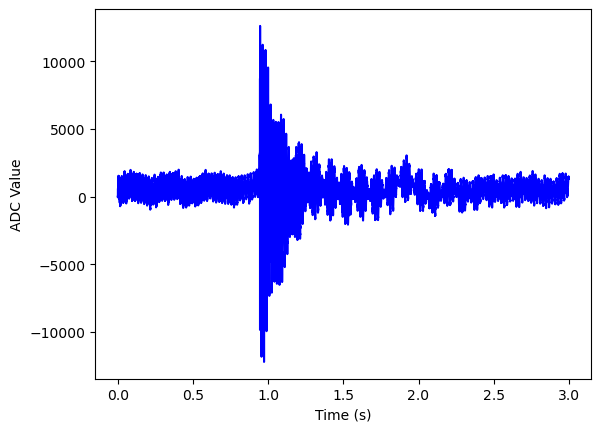

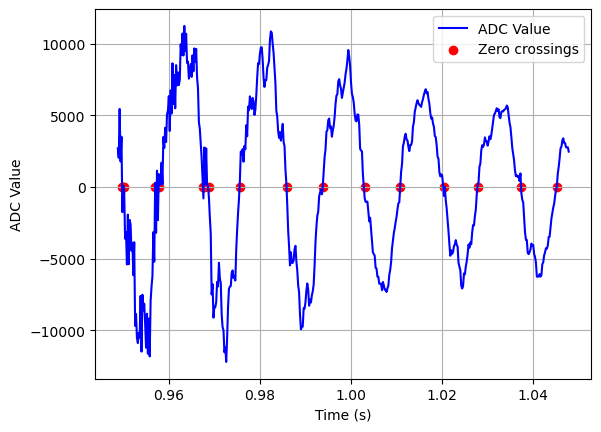

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#Import data into dataframe
df = pd.read_csv("10t3.csv")

#Used to centre x- and y- positions relative to neutral
df['ADC Value'] = df.iloc[:, 0] - df.iloc[0,0] 

#Must add time to the dataframe - how?
    #Ans: Use linspace feature and assign time value to each frame since we know the sample rate (5000Hz)
    #Also add another column as the 'frame counter' to check the frames and time given have synced up properly

df['Time (s)'] = np.arange(len(df))/5000
df['frameCount'] = np.arange(len(df))+1


#Apply BASIC filtering algorithm found from:
#("https://medium.com/@bhagyarana80/how-i-used-pandas-to-detect-anomalies-in-time-series-data-without-ml-7c1dbe8c736e")
df['rolling_meanADC'] = df['ADC Value'].rolling(window=24).mean()
df['rolling_stdADC'] = df['ADC Value'].rolling(window=24).std()

# Flag values > 3 std deviations from rolling mean
df['anomaly_rollingADC'] = (abs(df['ADC Value'] - df['rolling_meanADC']) > 3 * df['rolling_stdADC'])
df.loc[df['anomaly_rollingADC'] == True]

af = df[(df.anomaly_rollingADC == False)].copy()

af.iloc[af['ADC Value'].idxmax(), 2]
    
tStart = af.iloc[af['ADC Value'].idxmax(), 2] + 0.001
tEnd = af.iloc[af['ADC Value'].idxmax(), 2] + 0.1001

crop = af.loc[(af['Time (s)'] >= tStart) & (af['Time (s)'] <= tEnd)].copy()

ADCValue = crop["ADC Value"].to_numpy()
ADCSign = np.sign(ADCValue)

ADCSignChange = ((np.roll(ADCSign, 1) - ADCSign) != 0).astype(int)
ADCSignChange[0] = 0

crop['ADCSignChange'] = ADCSignChange

changeF = crop.loc[crop['ADCSignChange'] == 1]

# Zero crossing times
switchTimes = changeF['Time (s)'].to_numpy()
y = np.zeros_like(switchTimes)

# Time differences
tDiffsTemp = np.diff(switchTimes)
tDiffs = np.array([t for t in tDiffsTemp if t > 0.001])

# Frequency calculation
period = 2 * tDiffs.mean()
frequency = 1 / period

print(f"Test 1 for Length 10cm gave a frequency of {frequency:.2f} Hz.")


#Plot graphs of time vs x- and y-positions
df.plot(x='Time (s)', y='ADC Value', ylabel='ADC Value', color='blue', legend=False)
plt.savefig('Raw_ADC_Output', dpi=400, bbox_inches='tight')

# Cropped + zero crossings
crop.plot(x='Time (s)', y='ADC Value', ylabel='ADC Value', color='blue', grid=True)
plt.scatter(switchTimes, y, color='red', label='Zero crossings')
plt.legend()
plt.savefig('Cropped_ADC_Output', dpi=400, bbox_inches='tight')

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

testNumber = ["1","2","3","4","5"]
length = ["6", "7", "8", "9", "10", "11", "12"]
resultsF = {}
resultsP = {}

for L in length:
    
    resultsP[L] = []
    resultsF[L]= []

    for x in testNumber:
        #Import data into dataframe
        df = pd.read_csv(f"{L}t{x}.csv")
        
        #Used to centre x- and y- positions relative to neutral
        df['Amplitude'] = df.iloc[:, 0] - df.iloc[0,0] 
        
        #Must add time to the dataframe - how?
            #Ans: Use linspace feature and assign time value to each frame since we know the sample rate (5000Hz)
            #Also add another column as the 'frame counter' to check the frames and time given have synced up properly
        
        df['Time (s)'] = np.arange(len(df))/5000
        df['frameCount'] = np.arange(len(df))+1
        
        
        #Apply BASIC filtering algorithm found from:
        #("https://medium.com/@bhagyarana80/how-i-used-pandas-to-detect-anomalies-in-time-series-data-without-ml-7c1dbe8c736e")
        df['rolling_meanAmp'] = df['Amplitude'].rolling(window=24).mean()
        df['rolling_stdAmp'] = df['Amplitude'].rolling(window=24).std()
        
        # Flag values > 3 std deviations from rolling mean
        df['anomaly_rollingAmp'] = (abs(df['Amplitude'] - df['rolling_meanAmp']) > 3 * df['rolling_stdAmp'])
        df.loc[df['anomaly_rollingAmp'] == True]
        
        af = df[(df.anomaly_rollingAmp == False)].copy()
        
        af.iloc[af['Amplitude'].idxmax(), 2]
            
        tStart = af.iloc[af['Amplitude'].idxmax(), 2] + 0.001
        tEnd = af.iloc[af['Amplitude'].idxmax(), 2] + 0.1001
        
        crop = af.loc[(af['Time (s)'] >= tStart) & (af['Time (s)'] <= tEnd)].copy()
        
        Amplitude = crop["Amplitude"].to_numpy()
        AmpSign = np.sign(Amplitude)
        
        AmpSignChange = ((np.roll(AmpSign, 1) - AmpSign) != 0).astype(int)
        AmpSignChange[0] = 0
        
        crop['AmpSignChange'] = AmpSignChange
            
        changeF = crop.loc[crop['AmpSignChange'] == 1]
        
        #Converting to a NumPy array and assigning each value to a 0 to place it on the x-axis (i.e. where y==0)
        switchTimes = changeF['Time (s)'].to_numpy()
        y = np.zeros_like(switchTimes)
    
        
        tDiffsTemp = np.diff(switchTimes)
        tDiffs = np.array([x for x in tDiffsTemp if 0.001<x])
        tDiffs.mean()
        
        
        period = 2 * tDiffs.mean()
        resultsP[L].append(period)
        frequency = 1/period
        print(f"Test {x} for Length {L}cm gave a period of "+str('{:.5f}'.format(frequency))+" Hz.")
        resultsF[L].append(frequency)



Test 1 for Length 6cm gave a period of 162.33766 Hz.
Test 2 for Length 6cm gave a period of 159.79381 Hz.
Test 3 for Length 6cm gave a period of 168.16143 Hz.
Test 4 for Length 6cm gave a period of 168.84532 Hz.
Test 5 for Length 6cm gave a period of 158.99123 Hz.
Test 1 for Length 7cm gave a period of 117.09602 Hz.
Test 2 for Length 7cm gave a period of 119.04762 Hz.
Test 3 for Length 7cm gave a period of 112.90323 Hz.
Test 4 for Length 7cm gave a period of 119.04762 Hz.
Test 5 for Length 7cm gave a period of 119.33174 Hz.
Test 1 for Length 8cm gave a period of 100.00000 Hz.
Test 2 for Length 8cm gave a period of 97.92627 Hz.
Test 3 for Length 8cm gave a period of 105.88235 Hz.
Test 4 for Length 8cm gave a period of 98.25328 Hz.
Test 5 for Length 8cm gave a period of 98.90110 Hz.
Test 1 for Length 9cm gave a period of 71.42857 Hz.
Test 2 for Length 9cm gave a period of 77.77778 Hz.
Test 3 for Length 9cm gave a period of 80.09153 Hz.
Test 4 for Length 9cm gave a period of 80.09153 Hz.


In [150]:
for L in results:
    arr = np.array(resultsP[L])
    print(arr.mean()*10**3)

6.115393400074161
8.515428571428581
9.989019607843144
12.94857142857142
16.957333333333334
20.337777777777795
22.447142857142854


In [ ]:
    #Plot graphs of time vs x- and y-positions
    df.plot(x='Time (s)', y='Amplitude')

    af.plot(x='Time (s)', y='Amplitude')
        
    #Plotting graphs with zero crossings
    crop.plot(x='Time (s)', y='Amplitude', color = 'blue', grid = True)
    plt.scatter(switchTimes, y, color = 'red', label = 'Zero crossings')
    plt.legend()

In [147]:
U = {}


length_vals = []
mean_periods = []
errors = []

for L in results:
    arr = np.array(resultsP[L])
    
    length_vals.append(float(L)/100)
    
    mean = arr.mean()
    mean_periods.append(mean)
    
    U[L] = arr.max() - arr.min()   # store per length
    errors.append(U[L])
    
    p[L] = U[L] / mean    



m = 0.056
Length = 33.85 * 10 **-2

h = 0.8*10**-3
b = 25.36*10**-3
IIMoA = b*(h**3)/12

1.5761555547371937
0.16913234189273021


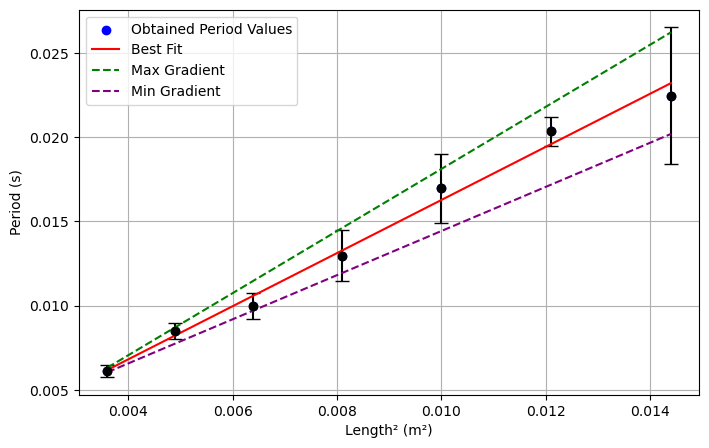

In [196]:
# Convert data
L = np.array(length_vals)
T = np.array(mean_periods)
dT = np.array(errors)

# Transform
x = L**2
y = T
yerr = dT

# Best fit
res = stats.linregress(x, y)
a, b = res.slope, res.intercept

# Max/min fits
res_max = stats.linregress(x, y + yerr)
res_min = stats.linregress(x, y - yerr)

a_max, b_max = res_max.slope, res_max.intercept
a_min, b_min = res_min.slope, res_min.intercept

# Smooth line
x_fit = np.linspace(min(x), max(x), 100)

plt.figure(figsize=(8, 5))

# Data
plt.scatter(x, y, color='blue', label='Obtained Period Values')
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=5, color='black')

# Lines
plt.plot(x_fit, a * x_fit + b, color='red', label='Best Fit')
plt.plot(x_fit, a_max * x_fit + b_max, '--', color='green', label='Max Gradient')
plt.plot(x_fit, a_min * x_fit + b_min, '--', color='purple', label='Min Gradient')

plt.xlabel("Length² (m²)")
plt.ylabel("Period (s)")
plt.legend()
plt.grid(True)


plt.savefig('ADC_Output', dpi=400, bbox_inches='tight')
print(a)
print(((a_max-a_min)/2)/a)

In [119]:
E = ((1/(0.56*a))*np.sqrt(m/Length)/np.sqrt(IIMoA))**2
print(E)

14349328564.46035


In [148]:
E = (m/Length) / (0.56 * 0.56 * a * a * ((b * (h ** 3))/12))
print(E)

196253396675.5712


In [144]:
A = ["Test 1 for Length 10cm gave a period of 58.54801 Hz."]

h = 0.8*(10**-3)
b = 25.52*(10**-3)
m = 0.056
Length = 33.85 * 10 **-2
E = 200*(10**9)
L = 0.1

IIMoA = b*(h**3)/12
q = m/Length

f = 0.56*np.sqrt(E*IIMoA/(q*(L**4)))
print(f)

64.24998643839028


In [ ]:
A = ["Test 1 for Length 10cm gave a period of 58.54801 Hz."]

h = 0.9*(10**-3)
b = 24.36*(10**-2)
m = 0.056
Length = 33.85 * 10 **-2
f = 58.54
L = 0.1

IIMoA = b*(h**3)/12
q = m/Length

E = ((f/0.56)**2)*(q*(L**4)/IIMoA)

print(E)